In [1]:
from pathlib import Path
import torch

from circuit_tracer import ReplacementModel, attribute
from circuit_tracer.utils import create_graph_files

model_name = "google/gemma-2-2b"
transcoder_name = "mntss/clt-gemma-2-2b-2.5M"
backend = 'transformerlens'  # change to 'nnsight' for the nnsight backend!
model = ReplacementModel.from_pretrained(
    model_name, transcoder_name, dtype=torch.bfloat16, lazy_encoder=True, backend=backend
)

Fetching 52 files:   0%|          | 0/52 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer


In [2]:
prompt = "Fact: The capital of state containing Dallas is"  # What you want to get the graph for
max_n_logits = 10  # How many logits to attribute from, max. We attribute to min(max_n_logits, n_logits_to_reach_desired_log_prob); see below for the latter
desired_logit_prob = 0.95  # Attribution will attribute from the minimum number of logits needed to reach this probability mass (or max_n_logits, whichever is lower)
max_feature_nodes = 8192  # Only attribute from this number of feature nodes, max. Lower is faster, but you will lose more of the graph. None means no limit.
batch_size = 256  # Batch size when attributing
offload = (
    "cpu"
)  # Offload various parts of the model during attribution to save memory. Can be 'disk', 'cpu', or None (keep on GPU)
verbose = True  # Whether to display a tqdm progress bar and timing report

In [3]:
graph = attribute(
    prompt=prompt,
    model=model,
    max_n_logits=max_n_logits,
    desired_logit_prob=desired_logit_prob,
    batch_size=batch_size,
    max_feature_nodes=max_feature_nodes,
    offload=offload,
    verbose=verbose,
)

Phase 0: Precomputing activations and vectors
Precomputation completed in 7.32s
Found 2932 active features
Phase 1: Running forward pass
Forward pass completed in 0.08s
Phase 2: Building input vectors
Using 10 salient logits with cumulative probability 0.7031
Will include 2932 of 2932 feature nodes
Input vectors built in 1.82s
Phase 3: Computing logit attributions
<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
Logit attributions completed in 0.21s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 2932/2932 [00:00<00:00, 4718.44it/s] 
Feature attributions completed in 0.62s
Attribution completed in 12.49s


In [4]:
graph_dir = "graphs"
graph_name = "example_graph.pt"
graph_dir = Path(graph_dir)
graph_dir.mkdir(exist_ok=True)
graph_path = graph_dir / graph_name

graph.to_pt(graph_path)

In [ ]:
import torch
import matplotlib.pyplot as plt
from circuit_tracer.graph import Graph, normalize_matrix, compute_influence


def plot_error_influence_per_layer(graph: Graph, ax=None):
    n_logits = len(graph.logit_targets)
    n_tokens = len(graph.input_tokens)
    n_features = len(graph.selected_features)
    n_layers = graph.cfg.n_layers

    error_start = n_features
    error_end = error_start + n_layers * n_tokens

    logit_weights = torch.zeros(
        graph.adjacency_matrix.shape[0], device=graph.adjacency_matrix.device
    )
    logit_weights[-n_logits:] = graph.logit_probabilities

    node_influence = compute_influence(normalize_matrix(graph.adjacency_matrix), logit_weights)

    # errors are stored as error[layer0][pos0..t-1], error[layer1][...], ...
    error_infl = node_influence[error_start:error_end].reshape(n_layers, n_tokens)
    per_layer = error_infl.sum(dim=-1).cpu()


    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(n_layers), per_layer.numpy())
    ax.set_xlabel("Layer")
    ax.set_ylabel("Error-node influence (summed over positions)")
    ax.set_title("Error node influence per layer")
    return ax, per_layer


In [ ]:
import torch
import matplotlib.pyplot as plt
from circuit_tracer.graph import Graph, normalize_matrix, compute_influence


def plot_influence_per_layer(graph: Graph):
    print(graph.adjacency_matrix.shape)
    n_logits = len(graph.logit_targets)
    n_tokens = len(graph.input_tokens)
    n_features = len(graph.selected_features)
    n_layers = graph.cfg.n_layers

    error_start = n_features
    error_end = error_start + n_layers * n_tokens

    logit_weights = torch.zeros(
        graph.adjacency_matrix.shape[0], device=graph.adjacency_matrix.device
    )
    logit_weights[-n_logits:] = graph.logit_probabilities

    node_influence = compute_influence(normalize_matrix(graph.adjacency_matrix), logit_weights)

    # Error influence per layer: errors are laid out as error[layer][pos]
    error_infl = node_influence[error_start:error_end].reshape(n_layers, n_tokens)
    error_per_layer = error_infl.sum(dim=-1).cpu()

    # Feature influence per layer: look up each selected feature's layer
    feature_layers = graph.active_features[graph.selected_features][:, 0]  # (n_features,)
    feature_infl = node_influence[:n_features].cpu()
    feature_per_layer = torch.zeros(n_layers)
    feature_per_layer.scatter_add_(0, feature_layers.cpu().long(), feature_infl)

    total_per_layer = feature_per_layer + error_per_layer

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    x = range(n_layers)

    axes[0].bar(x, error_per_layer.numpy())
    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Influence")
    axes[0].set_title("Error-node influence per layer")

    axes[1].bar(x, feature_per_layer.numpy(), label="features")
    axes[1].bar(x, error_per_layer.numpy(), bottom=feature_per_layer.numpy(), label="errors")
    axes[1].set_xlabel("Layer")
    axes[1].set_ylabel("Influence")
    axes[1].set_title("Total influence per layer (features + errors)")
    axes[1].legend()

    plt.tight_layout()
    return fig, {"error": error_per_layer, "feature": feature_per_layer, "total": total_per_layer}


torch.Size([4990, 4990])


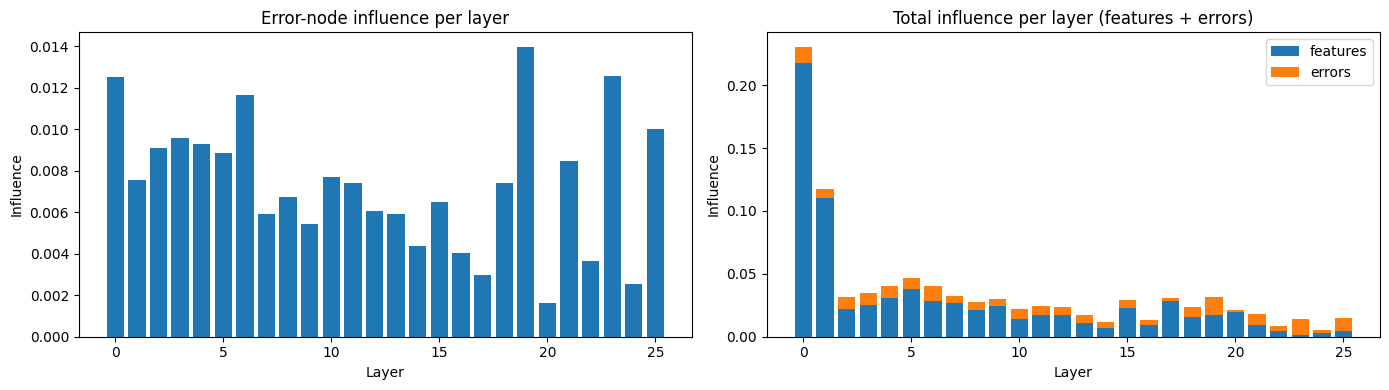

In [10]:
from circuit_tracer import Graph
g = Graph.from_pt("analogy_graphs/004.pt")
ax, per_layer = plot_influence_per_layer(g)
plt.show()

In [8]:
import torch
import matplotlib.pyplot as plt
from circuit_tracer.graph import Graph, normalize_matrix, compute_influence


def _influence_per_layer(graph: Graph):
    n_logits = len(graph.logit_targets)
    n_tokens = len(graph.input_tokens)
    n_features = len(graph.selected_features)
    n_layers = graph.cfg.n_layers

    error_start = n_features
    error_end = error_start + n_layers * n_tokens

    logit_weights = torch.zeros(
        graph.adjacency_matrix.shape[0], device=graph.adjacency_matrix.device
    )
    logit_weights[-n_logits:] = graph.logit_probabilities

    node_influence = compute_influence(normalize_matrix(graph.adjacency_matrix), logit_weights)

    error_per_layer = (
        node_influence[error_start:error_end].reshape(n_layers, n_tokens).sum(dim=-1).cpu()
    )

    feature_layers = graph.active_features[graph.selected_features][:, 0].long().cpu()
    feature_infl = node_influence[:n_features].cpu()
    feature_per_layer = torch.zeros(n_layers).scatter_add_(0, feature_layers, feature_infl)
    return feature_per_layer, error_per_layer


def plot_mean_influence_per_layer(graphs: list[Graph]):
    # assumes all graphs share n_layers (same model)
    n_layers = graphs[0].cfg.n_layers
    feats = torch.zeros(len(graphs), n_layers)
    errs = torch.zeros(len(graphs), n_layers)
    for i, g in enumerate(graphs):
        feats[i], errs[i] = _influence_per_layer(g)

    mean_feature = feats.mean(dim=0)
    mean_error = errs.mean(dim=0)
    mean_total = mean_feature + mean_error

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    x = range(n_layers)

    axes[0].bar(x, mean_error.numpy())
    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Mean influence")
    axes[0].set_title(f"Mean error-node influence per layer (n={len(graphs)})")

    axes[1].bar(x, mean_feature.numpy(), label="features")
    axes[1].bar(x, mean_error.numpy(), bottom=mean_feature.numpy(), label="errors")
    axes[1].set_xlabel("Layer")
    axes[1].set_ylabel("Mean influence")
    axes[1].set_title(f"Mean total influence per layer (n={len(graphs)})")
    axes[1].legend()

    plt.tight_layout()
    return fig, {"error": mean_error, "feature": mean_feature, "total": mean_total}


In [6]:
def feature_count_per_layer(graph):
    n_layers = graph.cfg.n_layers
    layers = graph.active_features[graph.selected_features][:, 0].long().cpu()
    return torch.bincount(layers, minlength=n_layers)


def mean_feature_count_per_layer(graphs):
    n_layers = graphs[0].cfg.n_layers
    counts = torch.stack([feature_count_per_layer(g) for g in graphs]).float()
    return counts.mean(dim=0), counts.std(dim=0)


In [7]:
from pathlib import Path
from circuit_tracer.graph import Graph

paths = sorted(Path("dataset/analogies").glob("*.pt"))
graphs = [Graph.from_pt(str(p)) for p in paths]

fig, stats = plot_mean_influence_per_layer(graphs)
plt.show()

26
26
26
26
26
26
26
26
26
26
26
26
26
26
26
26
26
26
26
26
26


KeyboardInterrupt: 

In [9]:
mean_counts, std_counts = mean_feature_count_per_layer(graphs)
for i, (m, s) in enumerate(zip(mean_counts.tolist(), std_counts.tolist())):
    print(f"layer {i:2d}: {m:6.2f} ± {s:5.2f}")

layer  0: 441.11 ± 85.49
layer  1: 217.38 ± 51.21
layer  2: 193.03 ± 61.20
layer  3: 241.23 ± 55.81
layer  4: 250.04 ± 36.30
layer  5: 338.54 ± 43.00
layer  6: 274.19 ± 40.15
layer  7: 297.87 ± 40.75
layer  8: 195.11 ± 37.35
layer  9: 311.79 ± 36.13
layer 10: 258.97 ± 43.10
layer 11: 247.56 ± 26.91
layer 12: 198.21 ± 25.25
layer 13: 165.87 ± 20.38
layer 14: 159.64 ± 17.25
layer 15: 162.41 ± 21.41
layer 16: 167.06 ± 29.85
layer 17: 153.64 ± 24.58
layer 18: 152.46 ± 26.96
layer 19: 125.20 ± 23.83
layer 20: 103.36 ± 26.76
layer 21:  86.57 ± 20.71
layer 22:  69.63 ± 24.15
layer 23:  60.12 ± 19.22
layer 24:  61.30 ± 20.18
layer 25:  24.37 ±  5.77


In [3]:
print(stats['total'])

tensor([0.3589, 0.1841, 0.0554, 0.0580, 0.0691, 0.0640, 0.0578, 0.0517, 0.0345,
        0.0465, 0.0313, 0.0257, 0.0265, 0.0228, 0.0252, 0.0228, 0.0248, 0.0322,
        0.0373, 0.0317, 0.0259, 0.0393, 0.0275, 0.0319, 0.0305, 0.0160])


In [6]:
from circuit_tracer.graph import Graph
from summarization.prune import prune_pt_graph, load_prune_graph

pg = load_prune_graph("/home/tu/circuit_tracer_mod/pruned_graph/analogies/clt-hp/softmax/node_0.01/006_prune_graph.pt")
# pg = prune_pt_graph("graphs/000.pt", node_threshold=0.02, edge_threshold=1)

In [7]:
pg.num_nodes, pg.num_edges

(16, 96)

In [8]:
from summarization.cluster import cluster_graph_spectral, cluster_graph_agglomerative, cluster_graph_with_labels

clusters = cluster_graph_spectral(pg, target_k=7, max_layer_span=4, max_sn=None, mean_method="arith", normalize_weights=True, decay_rate=0.1, enforce_dag=True, random_state=42, n_init=20)

print(len(clusters))

15


In [9]:
clusters = cluster_graph_agglomerative(pg, target_k=7, max_layer_span=20, max_sn=None, mean_method="arith", normalize_weights=False, decay_rate=1.0)

print(clusters)


[['0_18753_12', '1_12928_12', '1_57794_12'], ['14_38977_12'], ['16_7096_12'], ['17_10521_12', '17_64609_12', '17_14123_12', '18_5968_12', '18_72385_12', '18_85061_12', '18_11314_12', '18_97540_12', '19_26865_11', '19_26865_12', '19_96693_12', '19_13946_12', '20_24998_12'], ['22_29258_12', '22_96509_12', '22_40026_12', '22_44413_12', '22_59437_12', '23_18235_12', '23_44348_12'], ['24_79427_12'], ['25_288_12'], ['E_2_0'], ['E_651_1'], ['E_6508_2'], ['E_6128_3'], ['E_235292_4'], ['E_14449_5'], ['E_603_6'], ['E_577_7'], ['E_7033_8'], ['E_685_9'], ['E_2611_10'], ['E_603_11'], ['E_577_12'], ['27_4868_0']]


In [1]:
import pandas as pd

pd.set_option('display.max_rows', None)
df_cluster = pd.read_csv("eval_outputs/clustering/summary.csv")
df_cluster = df_cluster[df_cluster['k_selection'] != 'louvain_natural']

metrics = ['sil_norm', 'internal_independence', 'cv_cluster_sizes', 'opposing_sign_frac']
higher_is_better = {'sil_norm', 'internal_independence'}

table = (
    df_cluster
    .groupby(['method', 'k_selection'])[metrics]
    .mean()
    .unstack('k_selection')
)

# Flatten column names
table.columns = [f"{m}__{k}" for m, k in table.columns]

# Rank each metric (1 = best) per k_selection
ranked = pd.DataFrame(index=table.index)
for col in table.columns:
    metric = col.split("__")[0]
    ascending = metric not in higher_is_better
    ranked[col] = table[col].rank(ascending=ascending)

table['mean_rank'] = ranked.mean(axis=1)
table.sort_values('mean_rank').round(3)

,sil_norm__n_over_2,sil_norm__n_over_3,internal_independence__n_over_2,internal_independence__n_over_3,cv_cluster_sizes__n_over_2,cv_cluster_sizes__n_over_3,opposing_sign_frac__n_over_2,opposing_sign_frac__n_over_3,mean_rank
method,,,,,,,,,
ours-geo-decay-0.3,0.570,0.610,0.957,0.916,0.641,0.630,0.000,0.136,17.312
ours-arith-decay-0.2,0.559,0.598,0.971,0.902,0.464,0.598,0.083,0.087,17.375
ours-geo-decay-0.4,0.551,0.572,0.958,0.914,0.599,0.648,0.009,0.169,18.062
ours-arith-decay-0.0,0.683,0.761,0.958,0.905,0.625,0.622,0.089,0.057,18.500
ours-arith-decay-0.1,0.572,0.634,0.964,0.897,0.533,0.620,0.047,0.058,18.750
ours-harm-decay-0.4,0.567,0.602,0.959,0.914,0.619,0.677,0.021,0.159,18.875
ours-arith-decay-0.3,0.541,0.556,0.972,0.912,0.425,0.590,0.091,0.108,18.875
ours-geo-decay-0.2,0.577,0.608,0.956,0.906,0.652,0.663,0.000,0.120,19.688
ours-harm-decay-0.3,0.584,0.597,0.956,0.906,0.646,0.700,0.000,0.137,20.938


In [3]:
from circuit_tracer.utils.create_graph_files import create_graph_files_from_prune_graph

create_graph_files_from_prune_graph(pg, slug="example", output_path="graphs/example_graph.json")

In [7]:
from circuit_tracer.frontend.local_server import serve


port = 8046
server = serve(data_dir="graphs/", port=port)

from IPython.display import IFrame

print(f"Use the IFrame below, or open your graph here: f'http://localhost:{port}/index.html'")
display(IFrame(src=f"http://localhost:{port}/index.html", width="100%", height="800px"))

Use the IFrame below, or open your graph here: f'http://localhost:8046/index.html'


In [6]:
server.stop()